# X/Y 通道精细匹配测量

**固定 X 载波幅度，小范围扫描 Y 载波幅度。X/Y MOD 输入独立控制，可补偿偏置差异**。

## 实验设计

- **X 通道**: 载波固定（如 10 Vpp）
- **Y 通道**: 载波在 X 附近小范围扫描（如 ±0.1 Vpp）
- **X MOD**: dg_am CH1 DC, 独立控制 X 调制
- **Y MOD**: dg_am CH2 DC, 独立控制 Y 调制（含偏置补偿）
- **检测方式**: SDS 示波器 C2(X)/C3(Y) 直接测输出波形，正弦拟合提取幅值

## 硬件连接

| 信号 | 仪器 | 通道 | 说明 |
|------|------|------|------|
| X 载波 | DG4000 (dg_comp) | CH1 | 90kHz 正弦 + AM EXT → 示波器 CH2 |
| Y 载波 | DG4000 (dg_comp) | CH2 | 90kHz 正弦 + AM EXT → 示波器 CH3 |
| X AM DC | DG4000 (dg_am) | CH1 | DC → dg_comp CH1 MOD Input (独立) |
| Y AM DC | DG4000 (dg_am) | CH2 | DC → dg_comp CH2 MOD Input (独立+偏置) |
| 示波器 | SDS | C2, C3 | 直接测输出电压 |

## 目录

1. [环境准备与参数配置](#env) — 库导入、设备映射、实验参数
2. [载波配置与 AM 调制](#setup) — X 固定载波、Y 起始载波、AM EXT 调制
3. [2D 扫描采集](#acq) — 扫描 AM DC 电压 × Y 载波幅度，逐点保存波形
4. [正弦拟合与等幅点查找](#analysis) — 提取幅值，插值求等幅 Y 载波
5. [结果可视化](#viz) — 等幅点热力图、交叉曲线
6. [安全关闭](#cleanup)

<a id='env'></a>
## 1. 环境准备与参数配置

导入库、加载设备映射、定义实验参数、创建运行目录。

In [57]:
# ========== 交互式绘图 ==========
%matplotlib widget

from pathlib import Path
import sys
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import display

from signal_generator import DG4000Instrument
from sds_acquisition import SDSInstrument, SDSAcquisition, AcquisitionConfig, ChannelConfig
from lockin_amplifier import (
    HF2Instrument,
    SignalInputConfig, OscillatorConfig, DemodulatorConfig,
    demod,
)
from scipy.optimize import curve_fit
from tqdm import tqdm
EXPERIMENT_TYPE = "XY_AM_Transfer"
PURPOSE = "xy_fine_match"

print("所有库导入成功")

所有库导入成功


In [58]:
# 加载映射
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# ============================================================
# ========== 实验参数 ==========
# ============================================================

# ---- X/Y 载波参数 ----
XY_CARRIER_FREQ = 90e3        # 载波频率 (Hz)

# ★ 独立调制深度: CH1(X) 和 CH2(Y) 可分别设置
XY_AM_DEPTH_X = 100           # X 通道 CH1 AM 调制深度 (%)
XY_AM_DEPTH_Y = 100           # Y 通道 CH2 AM 调制深度 (%)

# ★ X 载波: 固定不变
X_CARRIER_AMPLITUDE = 10.0    # Vpp, CH1 固定

# ★ Y 载波: 在 X 附近小范围扫描
Y_CARRIER_MIN = 9.8         # 最小值 (Vpp)
Y_CARRIER_MAX = 10.2        # 最大值 (Vpp)
Y_CARRIER_STEPS = 21          # 点数

# ---- AM DC 电压扫描（dg_am CH1→X MOD, CH2→Y MOD）----
DC_VOLTAGES = np.linspace(-0.2, 1, 25)   # -0.2→1V, 25 点

# ★ MOD 偏置补偿: X/Y 零输出点不同, CH2 加偏置弥合差距
MOD_OFFSET_X = -0.143          # X 通道 MOD DC 偏置 (V)
MOD_OFFSET_Y = -0.119        # Y 通道 MOD DC 偏置 (V), +0.015V 补偿 -0.015V 差异

AMP_SETTLE_TIME = 0.1         # Y 载波切换稳定时间 (s)

# ---- 示波器参数 ----
SCOPE_SAMPLING_RATE = 500e3   # 500 kSa/s
SCOPE_TIME_WINDOW = 0.002     # 2 ms 窗口
SCOPE_CH_X = 2                # 示波器通道: X → C2
SCOPE_CH_Y = 3                # 示波器通道: Y → C3
SCOPE_VOLT_SCALE = 2.0        # V/div

# ---- 运行目录 ----
RUN_TAG = "xy_fine_match"

Y_CARRIER_AMPLITUDES = np.linspace(
    Y_CARRIER_MIN,
    Y_CARRIER_MAX,
    Y_CARRIER_STEPS
)

n_y = len(Y_CARRIER_AMPLITUDES)
n_dc = len(DC_VOLTAGES)
print("配置已加载")
print(f"  X 载波: {X_CARRIER_AMPLITUDE} Vpp (固定)")

print(f"  Y 载波: {Y_CARRIER_AMPLITUDES[0]:.2f}→{Y_CARRIER_AMPLITUDES[-1]:.2f} Vpp, {n_y} 点")
print(f"  示波器通道: C{SCOPE_CH_X}(X), C{SCOPE_CH_Y}(Y), {SCOPE_SAMPLING_RATE/1e3:.0f} kSa/s")

print(f"  DC 扫描: {DC_VOLTAGES[0]:.2f}→{DC_VOLTAGES[-1]:.2f} V, {n_dc} 点")
print(f"  总计: {n_dc}×{n_y} = {n_dc*n_y} 点")

配置已加载
  X 载波: 10.0 Vpp (固定)
  Y 载波: 9.80→10.20 Vpp, 21 点
  示波器通道: C2(X), C3(Y), 500 kSa/s
  DC 扫描: -0.20→1.00 V, 25 点
  总计: 25×21 = 525 点


<a id='setup'></a>
## 2. 载波配置与 AM 调制

X 载波固定，Y 载波设定初始值，使能 AM 外部调制。

In [59]:
devices = {}

try:

    # ---- DG4000: X/Y 载波 (dg_comp) ----
    dg_comp_cfg = MAPPING["X_magnetic_field"]
    dg_comp = DG4000Instrument(dg_comp_cfg["resource"], channel=1)
    dg_comp.connect()
    print(f"dg_comp 已连接: {dg_comp.idn()}")
    dg_comp.set_ref_clock_source("EXTernal")
    devices["dg_comp"] = dg_comp

    # ---- DG4000: Z 磁场 + AM DC 控制 (dg_sweep) ----
    dg_sweep_cfg = MAPPING["Z_magnetic_field"]
    dg_sweep = DG4000Instrument(dg_sweep_cfg["resource"], channel=1)
    dg_sweep.connect()
    print(f"dg_sweep 已连接: {dg_sweep.idn()}")
    dg_sweep.set_ref_clock_source("EXTernal")
    dg_sweep.setup_dc(0.0, channel=1)
    dg_sweep.set_output(False, channel=1)
    dg_sweep.set_output(False, channel=2)
    print(f"  -> CH1 (Z 场): OFF; CH2 (AM DC): OFF")
    devices["dg_sweep"] = dg_sweep

    # ---- DG4000: Pump 调制 (dg_mod) ----
    dg_mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(dg_mod_cfg["resource"], channel=1)
    dg_mod.connect()
    print(f"dg_mod 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温度开关 (dg_temp) ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"dg_temp 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- DG4000: 光功率 (dg_laser) ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG4000Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"dg_laser 已连接: {dg_laser.idn()}")
    devices["dg_laser"] = dg_laser

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

    # ---- DG4000: X/Y AM DC 独立控制 (dg_am) ----
    dg_am_cfg = MAPPING["X_magnetic_field_AM"]
    dg_am = DG4000Instrument(dg_am_cfg["resource"], channel=1)
    dg_am.connect()
    print(f"dg_am 已连接: {dg_am.idn()}")
    dg_am.set_ref_clock_source("EXTernal")
    # CH1 → X MOD, CH2 → Y MOD (独立!)
    dg_am.setup_dc(0.0, channel=1)
    dg_am.setup_dc(0.0, channel=2)
    dg_am.set_output(False, channel=1)
    dg_am.set_output(False, channel=2)
    devices["dg_am"] = dg_am

    # ---- SDS 示波器 ----
    scope_cfg = MAPPING.get("scope_waveform", {})
    scope_resource = scope_cfg.get("resource", "")
    scope = SDSInstrument(scope_resource)
    scope.connect()
    print(f"示波器已连接: {scope.idn()}")
    devices["scope"] = scope

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

dg_comp 已连接: Rigol Technologies,DG4162,DG4E234902522,00.01.14
dg_sweep 已连接: Rigol Technologies,DG4162,DG4E242401288,00.01.14
  -> CH1 (Z 场): OFF; CH2 (AM DC): OFF
dg_mod 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
dg_temp 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
dg_laser 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q280100002,00.02.01.00.02
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部
dg_am 已连接: Rigol Technologies,DG4162,DG4E231500376,00.01.14
示波器已连接: Siglent Technologies,SDS1204X HD,SDSEV82X900704,6.9.12.1.1.3.8

所有设备连接完成，共 8 个设备


In [60]:
dg_comp = devices["dg_comp"]
dg_sweep = devices["dg_sweep"]
dg_am = devices["dg_am"]
scope = devices["scope"]

# ---- 创建运行目录 ----
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
(raw_dir := run_dir / "raw").mkdir(exist_ok=True)
(results_dir := run_dir / "results").mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ---- 保存配置 ----
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "x_carrier_amplitude_Vpp": X_CARRIER_AMPLITUDE,
    "y_carrier_amplitudes_Vpp": Y_CARRIER_AMPLITUDES.tolist(),
    "xy_carrier_freq_Hz": XY_CARRIER_FREQ,
    "xy_am_depth_x_pct": XY_AM_DEPTH_X,
    "mod_offset_x_V": MOD_OFFSET_X,
    "mod_offset_y_V": MOD_OFFSET_Y,
    "dc_voltages_V": DC_VOLTAGES.tolist(),
    "scope": {
        "sampling_rate_Hz": SCOPE_SAMPLING_RATE,
        "time_window_s": SCOPE_TIME_WINDOW,
        "ch_x": SCOPE_CH_X,
        "ch_y": SCOPE_CH_Y,
        "volt_scale_V_per_div": SCOPE_VOLT_SCALE,
    },
}
with open(run_dir / "experiment_config.yaml", "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print("配置已保存")

运行目录: d:\Code\exp_agent\data\XY_AM_Transfer\0522_0904_xy_fine_match
配置已保存


In [61]:
# ---- 配置 dg_comp CH1/CH2 AM 外部调制 ----
# X (CH1): 固定载波, Y (CH2): 先用 Y 扫描范围中心值
y_init = Y_CARRIER_AMPLITUDES[Y_CARRIER_STEPS // 2]  # 中心点
print(f"配置 AM 外部调制: X={X_CARRIER_AMPLITUDE}Vpp (固定, 深度{XY_AM_DEPTH_X}%) | "
      f"Y={y_init:.2f}Vpp (初始, 深度{XY_AM_DEPTH_Y}%)")

dg_comp.setup_sine(freq=XY_CARRIER_FREQ, amplitude=X_CARRIER_AMPLITUDE, phase=0.0, channel=1)
dg_comp.set_mod_type("AM", channel=1)
dg_comp.set_mod_am_source("EXT", channel=1)
dg_comp.set_mod_am_depth(XY_AM_DEPTH_X, channel=1)
dg_comp.set_mod_state(True, channel=1)

dg_comp.setup_sine(freq=XY_CARRIER_FREQ, amplitude=y_init, phase=0.0, channel=2)
dg_comp.set_mod_type("AM", channel=2)
dg_comp.set_mod_am_source("EXT", channel=2)
dg_comp.set_mod_am_depth(XY_AM_DEPTH_Y, channel=2)
dg_comp.set_mod_state(True, channel=2)

dg_comp.set_output(True, channel=1)
dg_comp.set_output(True, channel=2)
print(f"dg_comp CH1(X): AM EXT {XY_CARRIER_FREQ/1e3:.0f}kHz, 深度{XY_AM_DEPTH_X}%, 载波{X_CARRIER_AMPLITUDE}Vpp")
print(f"dg_comp CH2(Y): AM EXT {XY_CARRIER_FREQ/1e3:.0f}kHz, 深度{XY_AM_DEPTH_Y}%, 载波{y_init:.2f}Vpp")

# ---- dg_am: 独立 X/Y MOD DC (带偏置补偿) ----
# CH1 →  dg_comp CH1 MOD (X)
# CH2 →  dg_comp CH2 MOD (Y), 加偏置补偿
dg_am.setup_dc(MOD_OFFSET_X, channel=1)
dg_am.setup_dc(MOD_OFFSET_Y, channel=2)
dg_am.set_output(True, channel=1)
dg_am.set_output(True, channel=2)
print(f"dg_am CH1(X MOD): DC={MOD_OFFSET_X:.3f}V  (偏置补偿)")
print(f"dg_am CH2(Y MOD): DC={MOD_OFFSET_Y:.3f}V  (偏置补偿)\n")

配置 AM 外部调制: X=10.0Vpp (固定, 深度100%) | Y=10.00Vpp (初始, 深度100%)
dg_comp CH1(X): AM EXT 90kHz, 深度100%, 载波10.0Vpp
dg_comp CH2(Y): AM EXT 90kHz, 深度100%, 载波10.00Vpp
dg_am CH1(X MOD): DC=-0.143V  (偏置补偿)
dg_am CH2(Y MOD): DC=-0.119V  (偏置补偿)



<a id='acq'></a>
## 3. 2D 扫描采集

扫描 AM DC 电压 × Y 载波幅度。X 载波固定不变。自适应调整示波器垂直档位（40%-90% 满格范围），逐点保存 `.npy`。

In [66]:
# ============================================================
# 2D 扫描: DC 电压 × Y 载波幅度 (X 固定) — 逐点保存 + 自适应档位
# ============================================================
print("=" * 60)
print("2D 精细匹配扫描开始 (自适应档位)")
print("=" * 60)

# 示波器基础配置 (scale 动态调整)
scope_cfg = AcquisitionConfig()
scope_cfg.sampling_rate = SCOPE_SAMPLING_RATE
scope_cfg.sampling_time = SCOPE_TIME_WINDOW
scope_cfg.acquire_delay = 0.3

scope_cfg.channels = [
    ChannelConfig(number=SCOPE_CH_X, enabled=True, scale=SCOPE_VOLT_SCALE, coupling="DC"),
    ChannelConfig(number=SCOPE_CH_Y, enabled=True, scale=SCOPE_VOLT_SCALE, coupling="DC"),
]
scope_cfg.trigger.mode = "AUTO"
scope_cfg.trigger.source = f"C{SCOPE_CH_X}"

acq = SDSAcquisition(scope)

n_dc_data = len(DC_VOLTAGES)
n_y_data = len(Y_CARRIER_AMPLITUDES)
n_total = n_dc_data * n_y_data
t_start = time.time()
time_axis_saved = False
VERT_DIVS = 4                       # 有效显示格数
SCALE_MIN = 0.02                    # 最小 V/div
scale_x_used = np.full(n_dc_data, np.nan)   # 记录每个 DC 点实际使用的 scale
scale_y_used = np.full_like(scale_x_used, np.nan)

pbar = tqdm(total=n_total, desc="采集波形", unit="pt")

try:
    for i_dc, dc_v in enumerate(DC_VOLTAGES):
        # X/Y 独立 MOD DC (dg_am, 带偏置补偿)
        dg_am.setup_dc(dc_v + MOD_OFFSET_X, channel=1)  # X MOD
        dg_am.setup_dc(dc_v + MOD_OFFSET_Y, channel=2)  # Y MOD (偏置补偿)

        # 自适应缩放仅在每个 DC 的第一个 Y 点进行, 后续复用
        scope_scale_x = scope_cfg.channels[0].scale
        scope_scale_y = scope_cfg.channels[1].scale

        for i_y, y_carr in enumerate(Y_CARRIER_AMPLITUDES):
            # X 载波始终不变，仅更新 Y 载波
            dg_comp.set_amplitude(y_carr, channel=2)
            time.sleep(AMP_SETTLE_TIME)

            file_tag = f"D{i_dc:02d}_Y{i_y:02d}"

            # 自适应缩放: 仅第一个 Y 点做 retry 循环, 后续直接用当前 scale
            max_retries = 3 if i_y == 0 else 1
            for retry in range(max_retries):
                try:
                    results = acq.acquire_all(scope_cfg)
                    if not results or len(results) < 2:
                        break

                    x_wave = results[0].voltage
                    y_wave = results[1].voltage
                    t_wave = results[0].time

                    if i_y == 0 and retry < 2:
                        # 仅第一个 Y 点做自适应缩放判断
                        abs_max_x = np.max(np.abs(x_wave))
                        abs_max_y = np.max(np.abs(y_wave))
                        full_scale_x = scope_scale_x * VERT_DIVS
                        full_scale_y = scope_scale_y * VERT_DIVS
                        need_retry = False

                        # 信号太小 (< 40% 满格)
                        if abs_max_x < 0.4 * full_scale_x and scope_scale_x > SCALE_MIN * 2:
                            scope_scale_x /= 2
                            scope_cfg.channels[0].scale = scope_scale_x
                            need_retry = True
                        if abs_max_y < 0.4 * full_scale_y and scope_scale_y > SCALE_MIN * 2:
                            scope_scale_y /= 2
                            scope_cfg.channels[1].scale = scope_scale_y
                            need_retry = True

                        # 信号太大 (> 90% 满格)
                        if abs_max_x > 0.9 * full_scale_x:
                            scope_scale_x *= 2
                            scope_cfg.channels[0].scale = scope_scale_x
                            need_retry = True
                        if abs_max_y > 0.9 * full_scale_y:
                            scope_scale_y *= 2
                            scope_cfg.channels[1].scale = scope_scale_y
                            need_retry = True

                        if need_retry:
                            tqdm.write(f"  DC={dc_v:.2f}V: 缩放 retry{retry+1} "
                                       f"(X→{scope_scale_x:.2f}V/div, Y→{scope_scale_y:.2f}V/div)")
                            continue  # 重采

                    # 保存波形
                    np.save(raw_dir / f"waveform_x_{file_tag}.npy", x_wave)
                    np.save(raw_dir / f"waveform_y_{file_tag}.npy", y_wave)

                    if not time_axis_saved:
                        np.save(raw_dir / "time_axis.npy", t_wave)
                        time_axis_saved = True

                    break  # 成功, 跳出 retry 循环

                except Exception as e:
                    tqdm.write(f"  scope error @ DC={dc_v:.2f}V, Y={y_carr:.2f}Vpp: {e}")
                    break

            pbar.update(1)
            pbar.set_postfix(DC=f"{dc_v:.2f}", Y=f"{y_carr:.2f}",
                           Xdiv=f"{scope_scale_x:.2f}", Ydiv=f"{scope_scale_y:.2f}")

        # 记录该 DC 点最终使用的 scale
        scale_x_used[i_dc] = scope_scale_x
        scale_y_used[i_dc] = scope_scale_y

except KeyboardInterrupt:
    tqdm.write(f"\n⚠ 用户中断扫描")
except Exception as e:
    tqdm.write(f"\n扫描出错: {e}")
    raise
finally:
    pbar.close()

elapsed = time.time() - t_start
avg_t = elapsed / n_total if n_total > 0 else 0
print(f"\n扫描完成! {n_total} 点, 用时 {elapsed:.0f}s ({avg_t:.2f}s/点)")

# ---- 保存扫描参数 (含自适应 scale 记录) ----
np.savez(raw_dir / "scan_params.npz",
         dc_voltages=DC_VOLTAGES,
         y_carrier_amplitudes=Y_CARRIER_AMPLITUDES,
         x_carrier_amplitude=X_CARRIER_AMPLITUDE,
         mod_offset_x=MOD_OFFSET_X,
         mod_offset_y=MOD_OFFSET_Y,
         scale_x_used=scale_x_used,
         scale_y_used=scale_y_used)
print(f"原始波形已保存至: {raw_dir}")

2D 精细匹配扫描开始 (自适应档位)


采集波形:   0%|          | 0/525 [00:00<?, ?pt/s]    

  DC=-0.20V: 缩放 retry1 (X→1.00V/div, Y→1.00V/div)


采集波形:   0%|          | 0/525 [00:01<?, ?pt/s]    

  DC=-0.20V: 缩放 retry2 (X→0.50V/div, Y→0.50V/div)


...

  DC=0.95V: 缩放 retry1 (X→1.00V/div, Y→0.50V/div)


采集波形:  92%|█████████▏| 483/525 [05:24<00:27,  1.50pt/s, DC=0.90, Xdiv=0.50, Y=10.20, Ydiv=0.50]    

  DC=0.95V: 缩放 retry2 (X→1.00V/div, Y→1.00V/div)


采集波形: 100%|██████████| 525/525 [05:51<00:00,  1.49pt/s, DC=1.00, Xdiv=1.00, Y=10.20, Ydiv=1.00]


扫描完成! 525 点, 用时 352s (0.67s/点)
原始波形已保存至: d:\Code\exp_agent\data\XY_AM_Transfer\0522_0904_xy_fine_match\raw


<a id='analysis'></a>
## 4. 正弦拟合与等幅点查找

正弦拟合提取幅值，对每个 DC 电压插值找到使 amp_y ≈ amp_x 的 Y 载波值。

In [67]:
# ============================================================
# 正弦拟合 + 插值找等幅 Y 载波
# ============================================================

from scipy.interpolate import interp1d

def sine_model(t, A, f, phi, offset):
    return A * np.sin(2 * np.pi * f * t + phi) + offset

# 加载时间轴
TIME_AXIS = np.load(raw_dir / "time_axis.npy")

# 加载扫描参数
sp = np.load(raw_dir / "scan_params.npz")
DC_VALS = sp["dc_voltages"]
Y_CARRIER_VALS = sp["y_carrier_amplitudes"]
X_CARR = float(sp["x_carrier_amplitude"])  # np.savez 标量返回 0-d array, 强制转 float
n_dc_data, n_y_data = len(DC_VALS), len(Y_CARRIER_VALS)

# 幅值容器: amp_x[dc_idx, y_idx], amp_y[dc_idx, y_idx]
amp_x = np.full((n_dc_data, n_y_data), np.nan)
amp_y = np.full_like(amp_x, np.nan)

print(f"对 {n_dc_data}×{n_y_data}={n_dc_data*n_y_data} 个点做正弦拟合...")

for i_dc in range(n_dc_data):
    for i_y in range(n_y_data):
        file_tag = f"D{i_dc:02d}_Y{i_y:02d}"
        path_x = raw_dir / f"waveform_x_{file_tag}.npy"
        path_y = raw_dir / f"waveform_y_{file_tag}.npy"
        if not path_x.exists() or not path_y.exists():
            continue

        x_wave = np.load(path_x)
        y_wave = np.load(path_y)
        t = TIME_AXIS[:len(x_wave)]

        try:
            A0_x = (np.max(x_wave) - np.min(x_wave)) / 2
            off0_x = (np.max(x_wave) + np.min(x_wave)) / 2
            popt_x, _ = curve_fit(sine_model, t, x_wave,
                                  p0=[A0_x, XY_CARRIER_FREQ, 0, off0_x],
                                  maxfev=10000)
            amp_x[i_dc, i_y] = abs(popt_x[0])

            A0_y = (np.max(y_wave) - np.min(y_wave)) / 2
            off0_y = (np.max(y_wave) + np.min(y_wave)) / 2
            popt_y, _ = curve_fit(sine_model, t, y_wave,
                                  p0=[A0_y, XY_CARRIER_FREQ, 0, off0_y],
                                  maxfev=10000)
            amp_y[i_dc, i_y] = abs(popt_y[0])
        except Exception as e:
            print(f"  拟合失败 {file_tag}: {e}")

n_fitted = np.sum(~np.isnan(amp_x))
print(f"拟合完成: {n_fitted}/{n_dc_data*n_y_data} 点成功")

# ── 对每个 DC, 插值找 amp_y ≈ amp_x 时的 Y 载波 ──
equal_y_carrier = np.full(n_dc_data, np.nan)  # 等幅 Y 载波
equal_amp = np.full(n_dc_data, np.nan)        # 等幅时的幅值

print(f"\n查找各 DC 下的等幅 Y 载波...")
for i_dc in range(n_dc_data):
    # amp_x 理论上是近似恒定的（同一 X 载波），用均值
    amp_x_mean = np.nanmean(amp_x[i_dc, :])
    if np.isnan(amp_x_mean):
        continue

    # 插值: amp_y → y_carrier, 找 amp_y(y_carrier) = amp_x_mean 的点
    mask = ~np.isnan(amp_y[i_dc, :])
    if np.sum(mask) < 3:
        continue

    try:
        interp_y = interp1d(amp_y[i_dc, :][mask], Y_CARRIER_VALS[mask],
                            kind="linear", fill_value="extrapolate")
        y_eq = float(interp_y(amp_x_mean))
        # 校验是否在扫描范围内
        if Y_CARRIER_VALS[0] - 0.05 <= y_eq <= Y_CARRIER_VALS[-1] + 0.05:
            equal_y_carrier[i_dc] = y_eq
            equal_amp[i_dc] = amp_x_mean
            print(f"  DC={DC_VALS[i_dc]:.2f}V: Y_eq={y_eq:.4f} Vpp (X={X_CARR}Vpp)")
        else:
            print(f"  DC={DC_VALS[i_dc]:.2f}V: Y_eq={y_eq:.4f} 超出扫描范围, 跳过")
    except Exception as e:
        print(f"  DC={DC_VALS[i_dc]:.2f}V: 插值失败 ({e})")

# 保存结果
np.savez(results_dir / "equal_output_results.npz",
         dc_voltages=DC_VALS,
         x_carrier_amplitude=X_CARR,
         y_carrier_amplitudes=Y_CARRIER_VALS,
         amp_x=amp_x, amp_y=amp_y,
         equal_y_carrier=equal_y_carrier,
         equal_amp=equal_amp)

对 25×21=525 个点做正弦拟合...
拟合完成: 525/525 点成功

查找各 DC 下的等幅 Y 载波...
  DC=-0.20V: Y_eq=8.7626 超出扫描范围, 跳过
  DC=-0.15V: Y_eq=9.9776 Vpp (X=10.0Vpp)
  DC=-0.10V: Y_eq=9.7982 Vpp (X=10.0Vpp)
  DC=-0.05V: Y_eq=10.0835 Vpp (X=10.0Vpp)
  DC=-0.00V: Y_eq=12.0769 超出扫描范围, 跳过
  DC=0.05V: Y_eq=17.6542 超出扫描范围, 跳过
  DC=0.10V: Y_eq=9.9908 Vpp (X=10.0Vpp)
  DC=0.15V: Y_eq=9.9652 Vpp (X=10.0Vpp)
  DC=0.20V: Y_eq=9.2868 超出扫描范围, 跳过
  DC=0.25V: Y_eq=9.9430 Vpp (X=10.0Vpp)
  DC=0.30V: Y_eq=10.1907 Vpp (X=10.0Vpp)
  DC=0.35V: Y_eq=9.9659 Vpp (X=10.0Vpp)
  DC=0.40V: Y_eq=9.9815 Vpp (X=10.0Vpp)
  DC=0.45V: Y_eq=9.7950 Vpp (X=10.0Vpp)
  DC=0.50V: Y_eq=9.8928 Vpp (X=10.0Vpp)
  DC=0.55V: Y_eq=10.0038 Vpp (X=10.0Vpp)
  DC=0.60V: Y_eq=9.9889 Vpp (X=10.0Vpp)
  DC=0.65V: Y_eq=9.9361 Vpp (X=10.0Vpp)
  DC=0.70V: Y_eq=9.8018 Vpp (X=10.0Vpp)
  DC=0.75V: Y_eq=9.8755 Vpp (X=10.0Vpp)
  DC=0.80V: Y_eq=9.9841 Vpp (X=10.0Vpp)
  DC=0.85V: Y_eq=9.9662 Vpp (X=10.0Vpp)
  DC=0.90V: Y_eq=9.8730 Vpp (X=10.0Vpp)
  DC=0.95V: Y_eq=9.8578 Vpp 

<a id='viz'></a>
## 5. 结果可视化

横轴为 AM DC 电压，纵轴为实际输出比 Amp_Y / Amp_X。每个 Y 载波幅度一条曲线，观察两通道输出一致性。


全局最优 Y 载波 (固定值, RMS 偏差最小):
  Y_best = 10.0800 Vpp  (X = 10.0 Vpp)
  RMS deviation from 1.0 = 0.063417
  推荐在实验中设置 dg_comp CH2 载波为 10.0800 Vpp


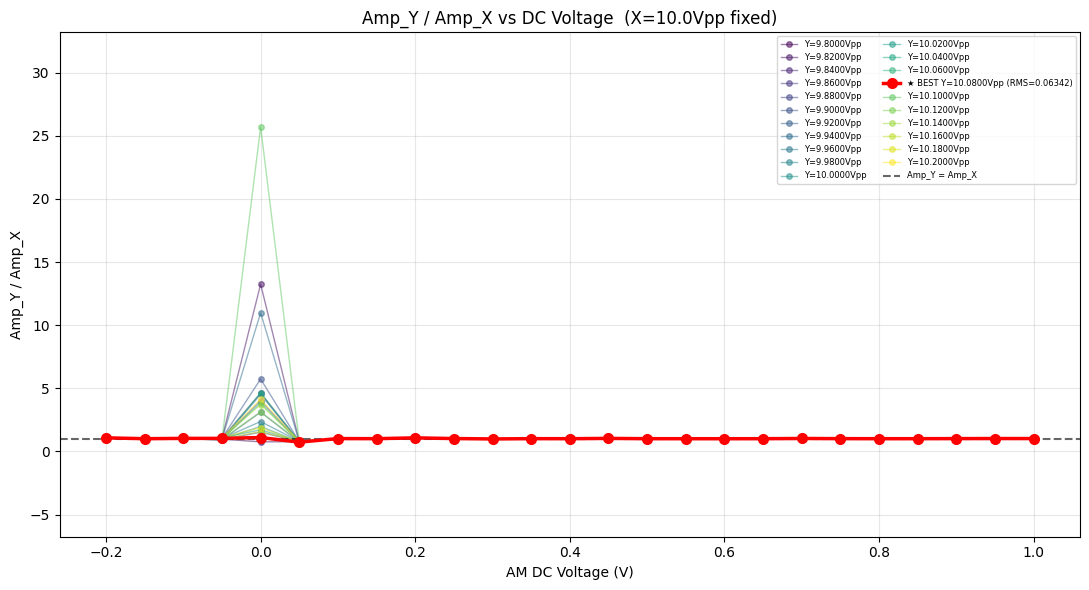

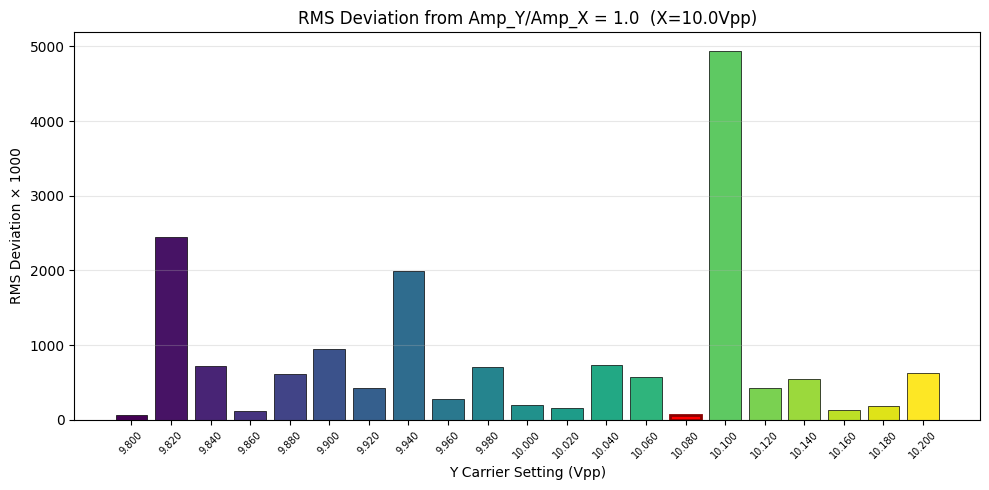

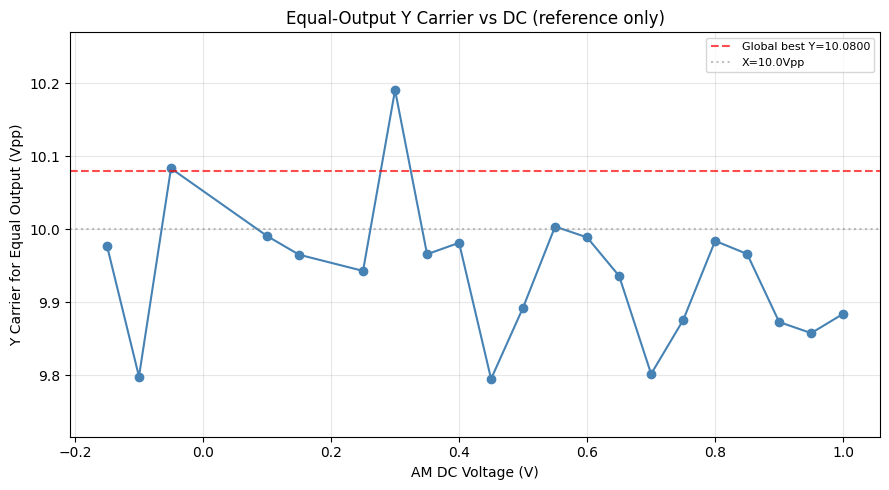


幅值比统计 (Amp_Y/Amp_X 全部数据):
  均值 = 1.161135 ± 1.350617
  范围 = [0.737547, 25.710906]

等幅 Y 载波统计 (不同 DC 插值, 仅供参考):
  逐 DC 均值 = 9.9407 ± 0.0927 Vpp
  有效点数: 21/25

分析结果已保存: d:\Code\exp_agent\data\XY_AM_Transfer\0522_0904_xy_fine_match\results
✅ 精细匹配分析完成!


In [68]:
# ============================================================
# 可视化: 横轴=AM DC电压, 纵轴=Amp_Y/Amp_X, 各 Y 载波一条线
# 自动评选全局最优 Y 载波 (RMS 偏离 1.0 最小)
# ============================================================
colors = plt.cm.viridis(np.linspace(0, 1, n_y_data))

# ── 计算每条 Y_carrier 曲线偏离 1.0 的 RMS ──
ratio_all = amp_y / amp_x  # (n_dc, n_y)
rms_deviation = np.full(n_y_data, np.nan)
for i_y in range(n_y_data):
    dev = ratio_all[:, i_y] - 1.0
    valid = ~np.isnan(dev)
    if np.sum(valid) >= 3:
        rms_deviation[i_y] = np.sqrt(np.nanmean(dev[valid] ** 2))

best_idx = np.nanargmin(rms_deviation)
best_y = Y_CARRIER_VALS[best_idx]
best_rms = rms_deviation[best_idx]
print(f"\n全局最优 Y 载波 (固定值, RMS 偏差最小):")
print(f"  Y_best = {best_y:.4f} Vpp  (X = {X_CARR} Vpp)")
print(f"  RMS deviation from 1.0 = {best_rms:.6f}")
print(f"  推荐在实验中设置 dg_comp CH2 载波为 {best_y:.4f} Vpp")

# ---- (a) Amp_Y/Amp_X vs DC, 每条 Y_carrier 一条曲线 ----
fig1, ax1 = plt.subplots(figsize=(11, 6))

for i_y, y_carr in enumerate(Y_CARRIER_VALS):
    ratio = ratio_all[:, i_y]
    if i_y == best_idx:
        # 高亮最优曲线
        ax1.plot(DC_VALS, ratio, "o-", ms=7, lw=2.5,
                 color="red", zorder=5,
                 label=f"★ BEST Y={y_carr:.4f}Vpp (RMS={best_rms:.5f})")
    else:
        ax1.plot(DC_VALS, ratio, "o-", ms=4, lw=1.0,
                 color=colors[i_y], alpha=0.5,
                 label=f"Y={y_carr:.4f}Vpp")

ax1.axhline(y=1.0, color="k", ls="--", lw=1.5, alpha=0.6, label="Amp_Y = Amp_X")
ax1.set_xlabel("AM DC Voltage (V)")
ax1.set_ylabel("Amp_Y / Amp_X")
ax1.set_title(f"Amp_Y / Amp_X vs DC Voltage  (X={X_CARR}Vpp fixed)")
ax1.legend(fontsize=6, ncol=2, loc="best")
ax1.grid(True, alpha=0.3)

# 自适应 Y 范围
all_ratios = ratio_all.flatten()
valid_ratios = all_ratios[~np.isnan(all_ratios)]
if len(valid_ratios) > 0:
    r_min, r_max = np.nanmin(valid_ratios), np.nanmax(valid_ratios)
    margin = max(0.02, (r_max - r_min) * 0.3)
    ax1.set_ylim(r_min - margin, r_max + margin)

plt.tight_layout()
display(fig1)
fig1.savefig(results_dir / "ratio_vs_dc_all_carriers.png", dpi=150)
plt.close(fig1)

# ---- (b) 各 Y 载波的 RMS 偏差条图 ----
fig2, ax2 = plt.subplots(figsize=(10, 5))
bars = ax2.bar(range(n_y_data), rms_deviation * 1000, color=colors, edgecolor="k", lw=0.5)
bars[best_idx].set_color("red")
bars[best_idx].set_edgecolor("darkred")
bars[best_idx].set_linewidth(2)

ax2.set_xticks(range(n_y_data))
ax2.set_xticklabels([f"{v:.3f}" for v in Y_CARRIER_VALS], rotation=45, fontsize=7)
ax2.set_xlabel("Y Carrier Setting (Vpp)")
ax2.set_ylabel("RMS Deviation × 1000")
ax2.set_title(f"RMS Deviation from Amp_Y/Amp_X = 1.0  (X={X_CARR}Vpp)")
ax2.axhline(y=0, color="k", lw=0.5)
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
display(fig2)
fig2.savefig(results_dir / "rms_vs_y_carrier.png", dpi=150)
plt.close(fig2)

# ---- (c) 等幅 Y 载波 vs DC 电压 (插值结果, 参考) ----
fig3, ax3 = plt.subplots(figsize=(9, 5))

valid_eq = ~np.isnan(equal_y_carrier)
ax3.plot(DC_VALS[valid_eq], equal_y_carrier[valid_eq], "o-", ms=6, color="steelblue")
ax3.axhline(y=best_y, color="red", ls="--", lw=1.5, alpha=0.7,
            label=f"Global best Y={best_y:.4f}")
ax3.axhline(y=X_CARR, color="gray", ls=":", alpha=0.5, label=f"X={X_CARR}Vpp")
ax3.set_xlabel("AM DC Voltage (V)")
ax3.set_ylabel("Y Carrier for Equal Output (Vpp)")
ax3.set_title(f"Equal-Output Y Carrier vs DC (reference only)")
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

if np.sum(valid_eq) >= 2:
    margin = max(0.02, (np.nanmax(equal_y_carrier) - np.nanmin(equal_y_carrier)) * 0.2)
    ax3.set_ylim(np.nanmin(equal_y_carrier) - margin, np.nanmax(equal_y_carrier) + margin)

plt.tight_layout()
display(fig3)
fig3.savefig(results_dir / "equal_y_vs_dc.png", dpi=150)
plt.close(fig3)

# ---- 统计输出 ----
print(f"\n幅值比统计 (Amp_Y/Amp_X 全部数据):")
print(f"  均值 = {np.nanmean(valid_ratios):.6f} ± {np.nanstd(valid_ratios):.6f}")
print(f"  范围 = [{np.nanmin(valid_ratios):.6f}, {np.nanmax(valid_ratios):.6f}]")

if np.sum(valid_eq) > 0:
    print(f"\n等幅 Y 载波统计 (不同 DC 插值, 仅供参考):")
    print(f"  逐 DC 均值 = {np.nanmean(equal_y_carrier):.4f} ± {np.nanstd(equal_y_carrier):.4f} Vpp")
    print(f"  有效点数: {np.sum(valid_eq)}/{n_dc_data}")

# ---- 保存分析结果 ----
analysis = {
    "experiment_type": EXPERIMENT_TYPE,
    "method": "sine_fit_equal_output",
    "carrier_freq_Hz": XY_CARRIER_FREQ,
    "am_depth_x_pct": XY_AM_DEPTH_X,
    "am_depth_y_pct": XY_AM_DEPTH_Y,
    "mod_offset_x_V": MOD_OFFSET_X,
    "mod_offset_y_V": MOD_OFFSET_Y,
    "x_carrier_amplitude_Vpp": X_CARR,
    "recommended_y_carrier_Vpp": float(best_y),
    "recommended_y_rms_deviation": float(best_rms),
    "recommendation_note":
        "此 Y 为全局固定值, 使整个 AM DC 范围内 Amp_Y/Amp_X 最接近 1.0",
    "y_carrier_amplitudes_Vpp": Y_CARRIER_VALS.tolist(),
    "rms_deviation_by_y": rms_deviation.tolist(),
    "n_fitted": int(n_fitted),
    "amp_ratio_stats": {
        "mean": float(np.nanmean(valid_ratios)),
        "std": float(np.nanstd(valid_ratios)),
        "min": float(np.nanmin(valid_ratios)),
        "max": float(np.nanmax(valid_ratios)),
    },
}
with open(results_dir / "analysis.yaml", "w", encoding="utf-8") as f:
    yaml.dump(analysis, f, default_flow_style=False, allow_unicode=True)

print(f"\n分析结果已保存: {results_dir}")
print(f"✅ 精细匹配分析完成!")

  10.06 Vpp → Y[13] = 10.0600 Vpp
  10.08 Vpp → Y[14] = 10.0800 Vpp


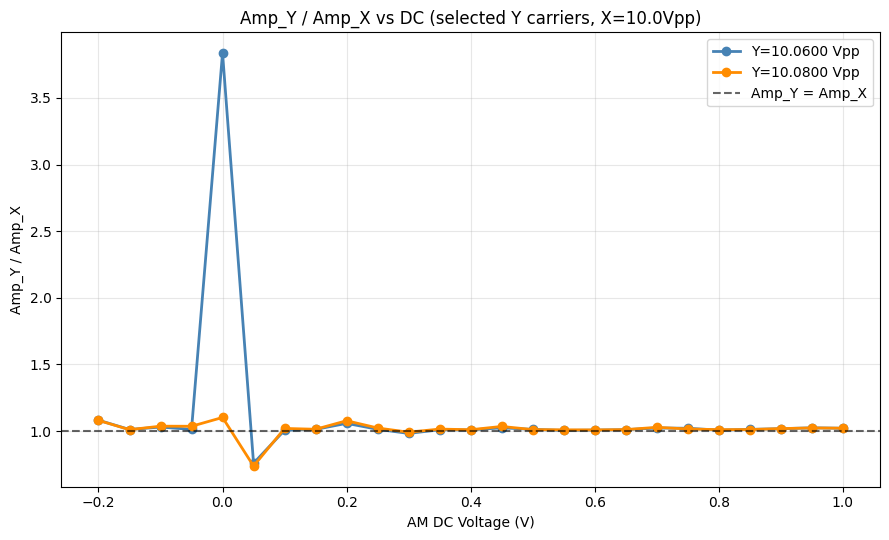


   DC(V)  Y=10.0600  Y=10.0800
  -0.200    1.08182    1.08044
  -0.150    1.01192    1.01062
  -0.100    1.03049    1.03690
  -0.050    1.01264    1.03621
  -0.000    3.83779    1.10233
   0.050    0.75862    0.73755
   0.100    1.00631    1.01991
   0.150    1.01271    1.01389
   0.200    1.05811    1.07779
   0.250    1.01374    1.02331
   0.300    0.98255    0.99179
   0.350    1.01016    1.01516
   0.400    1.00842    1.01028
   0.450    1.02506    1.03497
   0.500    1.01270    1.01124
   0.550    1.00512    1.00949
   0.600    1.00751    1.00888
   0.650    1.01045    1.01121
   0.700    1.02352    1.02832
   0.750    1.02138    1.01603
   0.800    1.00708    1.01095
   0.850    1.01283    1.01156
   0.900    1.01797    1.01885
   0.950    1.02453    1.02369
   1.000    1.02137    1.02183


In [72]:
# ============================================================
# 指定 Y 载波值的 Amp_Y/Amp_X vs DC 曲线
# ============================================================
target_y = [10.06, 10.08]  # 感兴趣的 Y 载波值 (Vpp)

# 找最接近的索引
indices = []
for ty in target_y:
    idx = np.argmin(np.abs(Y_CARRIER_VALS - ty))
    indices.append(idx)
    print(f"  {ty:.2f} Vpp → Y[{idx}] = {Y_CARRIER_VALS[idx]:.4f} Vpp")

fig, ax = plt.subplots(figsize=(9, 5.5))
colors_sel = ["steelblue", "darkorange", "forestgreen"]

for k, (idx, ty) in enumerate(zip(indices, target_y)):
    ratio = ratio_all[:, idx]
    ax.plot(DC_VALS, ratio, "o-", ms=6, lw=2, color=colors_sel[k],
            label=f"Y={Y_CARRIER_VALS[idx]:.4f} Vpp")

ax.axhline(y=1.0, color="k", ls="--", lw=1.5, alpha=0.6, label="Amp_Y = Amp_X")
ax.set_xlabel("AM DC Voltage (V)")
ax.set_ylabel("Amp_Y / Amp_X")
ax.set_title(f"Amp_Y / Amp_X vs DC (selected Y carriers, X={X_CARR}Vpp)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)
fig.savefig(results_dir / "ratio_vs_dc_selected.png", dpi=150)
plt.close(fig)

# 打印数值
print(f"\n{'DC(V)':>8s}", end="")
for idx in indices:
    print(f"  Y={Y_CARRIER_VALS[idx]:.4f}", end="")
print()
for i_dc, dc_v in enumerate(DC_VALS):
    print(f"{dc_v:8.3f}", end="")
    for idx in indices:
        r = ratio_all[i_dc, idx]
        if np.isnan(r):
            print(f"  {'NaN':>9s}", end="")
        else:
            print(f"  {r:9.5f}", end="")
    print()

<a id='cleanup'></a>
## 6. 安全关闭

In [ ]:
# ---- 断开所有设备（保持输出状态不变） ----

print("正在断开设备...")
print("（所有设备输出状态保持当前设置不变）")

# 仅断开连接，不改变任何输出状态
for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("所有设备已断开")